In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [34]:
# We need a reference date to calculate Recency.
analysis_date = df["order_date"].max()

print("Analysis Date:", analysis_date)

Analysis Date: 2026-06-30 00:00:00


In [35]:
# Calculating Recency
last_purchase = (
    df.groupby("customer_id")["order_date"]
      .max()
)

In [36]:
recency = (
    analysis_date - last_purchase
).dt.days

In [37]:
recency.head()

customer_id
C0001    44
C0002    12
C0003    17
C0004    55
C0005    25
Name: order_date, dtype: int64

In [38]:
# Calculating Frequency
frequency = (
    df.groupby("customer_id")["order_id"]
      .nunique()
)

In [39]:
frequency.head()

customer_id
C0001     7
C0002     9
C0003    13
C0004    16
C0005     4
Name: order_id, dtype: int64

In [40]:
# Calculating Monetary
monetary = (
    df.groupby("customer_id")["net_sales"]
      .sum()
)

In [41]:
monetary.head()

customer_id
C0001     135820.0
C0002     300600.0
C0003     878500.0
C0004    1108185.0
C0005     100500.0
Name: net_sales, dtype: float64

In [42]:
# Combine R, F and M 
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

In [43]:
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
C0001,44,7,135820.0
C0002,12,9,300600.0
C0003,17,13,878500.0
C0004,55,16,1108185.0
C0005,25,4,100500.0


In [44]:
# RFM scores 
# Recency score
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

In [45]:
# frequency score 
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [46]:
# Monetary score
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [47]:
# Now combine the three scores
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)


In [48]:
# the scores into business-friendly segments
def segment_customer(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Hibernating"

    else:
        return "Regular Customers"

In [49]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [50]:
# Inspecting segments
rfm["Segment"].value_counts()

Segment
Hibernating            108
At Risk                 91
Regular Customers       85
Loyal Customers         82
Champions               74
Potential Loyalists     60
Name: count, dtype: int64

In [51]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(
           Customers=("Monetary", "count"),
           Revenue=("Monetary", "sum"),
           Avg_Revenue=("Monetary", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Recency=("Recency", "mean")
       )
       .sort_values("Revenue", ascending=False)
)

In [52]:
segment_summary

,Customers,Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency
Segment,,,,,
Champions,74,65873835.0,890186.959459,13.689189,12.121622
At Risk,91,56844075.0,624660.164835,11.153846,91.945055
Loyal Customers,82,49131140.0,599160.243902,12.951220,26.963415
Hibernating,108,43932195.0,406779.583333,6.842593,112.824074
Regular Customers,85,40810320.0,480121.411765,8.635294,26.647059
Potential Loyalists,60,22502735.0,375045.583333,7.283333,11.983333


In [53]:
# Calculating revenue condition 
segment_summary["Revenue_Contribution"] = (
    segment_summary["Revenue"]
    / rfm["Monetary"].sum()
    * 100
)

In [54]:
segment_summary["Revenue_Contribution"] = (
    segment_summary["Revenue_Contribution"]
    .round(2)
)

In [55]:
segment_summary

,Customers,Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency,Revenue_Contribution
Segment,,,,,,
Champions,74,65873835.0,890186.959459,13.689189,12.121622,23.60
At Risk,91,56844075.0,624660.164835,11.153846,91.945055,20.37
Loyal Customers,82,49131140.0,599160.243902,12.951220,26.963415,17.60
Hibernating,108,43932195.0,406779.583333,6.842593,112.824074,15.74
Regular Customers,85,40810320.0,480121.411765,8.635294,26.647059,14.62
Potential Loyalists,60,22502735.0,375045.583333,7.283333,11.983333,8.06


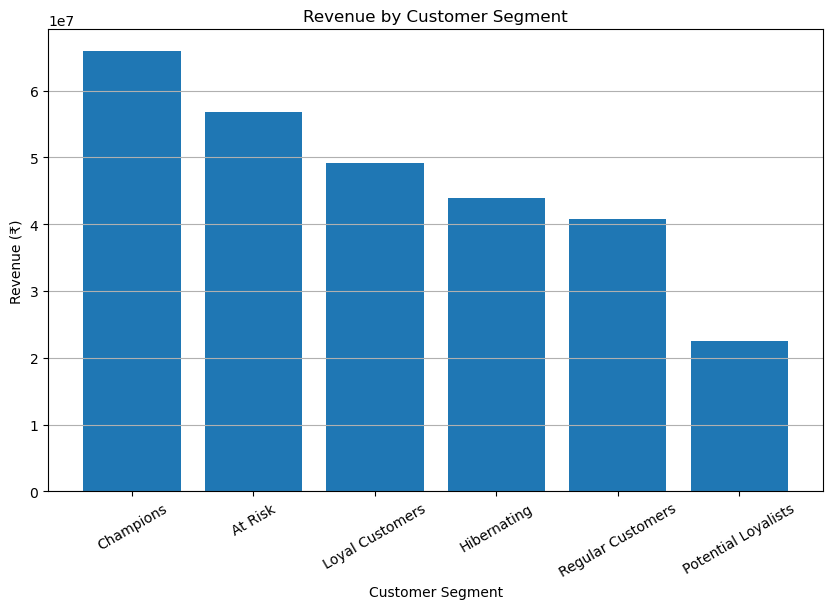

In [56]:
# Visualize customer segments
plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary.index,
    segment_summary["Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [57]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
)

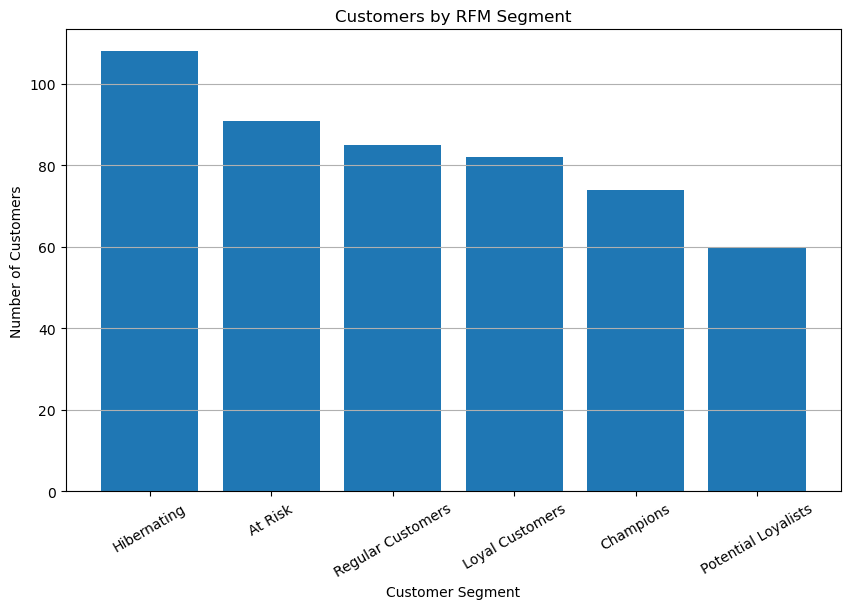

In [58]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customers by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [59]:
# Champions
champions = rfm[
    rfm["Segment"] == "Champions"
].sort_values(
    "Monetary",
    ascending=False
)

In [60]:
champions.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
customer_id,,,,,,,,
C0127,6,13,1523575.0,5,4,5,545,Champions
C0307,6,11,1475130.0,5,4,5,545,Champions
C0159,7,22,1382975.0,5,5,5,555,Champions
C0215,25,13,1382075.0,4,5,5,455,Champions
C0456,8,20,1319975.0,5,5,5,555,Champions
C0275,12,15,1266725.0,5,5,5,555,Champions
C0272,18,14,1226655.0,4,5,5,455,Champions
C0374,17,19,1210735.0,4,5,5,455,Champions
C0335,26,19,1173135.0,4,5,5,455,Champions


In [61]:
# business-action table
segment_actions = pd.DataFrame({
    "Segment": [
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "At Risk",
        "Hibernating",
        "Regular Customers"
    ],
    "Suggested_Action": [
        "Reward and retain",
        "Strengthen loyalty",
        "Encourage repeat purchases",
        "Win-back campaign",
        "Re-engagement campaign",
        "Nurture toward loyalty"
    ]
})

segment_actions

,Segment,Suggested_Action
0,Champions,Reward and retain
1,Loyal Customers,Strengthen loyalty
2,Potential Loyalists,Encourage repeat purchases
3,At Risk,Win-back campaign
4,Hibernating,Re-engagement campaign
5,Regular Customers,Nurture toward loyalty


# Day 11 — RFM Customer Segmentation Insights

## RFM Framework

RFM analysis evaluates customers using three dimensions:

- **Recency:** How recently a customer made a purchase.
- **Frequency:** How often a customer made purchases.
- **Monetary:** How much revenue a customer generated.

This analysis helps DataPulse move beyond simple revenue reporting and identify customer groups with different behavioral and business values.

---

## Champions

The **Champions** segment contains customers who have purchased recently, purchase frequently, and generate relatively high revenue.

This segment represents some of the most valuable customers in the business. They should be prioritized for retention initiatives, loyalty programs, personalized offers, and other strategies designed to maintain their engagement.

---

##  Loyal Customers

The **Loyal Customers** segment demonstrates strong purchasing frequency and continued engagement with the business.

These customers already show valuable purchasing behavior and could potentially be encouraged to increase their spending or become Champions through targeted loyalty strategies.

---

## Potential Loyalists

The **Potential Loyalists** segment consists of customers who have purchased relatively recently but have not yet developed strong purchasing frequency.

These customers represent an opportunity for the business because their recent activity suggests potential for further engagement. Personalized recommendations, follow-up offers, or incentives for another purchase could help move them toward the Loyal Customer segment.


---

##  At-Risk Customers

The **At-Risk** segment contains customers whose recent purchasing activity is weaker despite having demonstrated relatively strong purchasing behavior in the past.

These customers deserve particular attention because losing a previously valuable customer may have a greater financial impact than losing a low-value customer.

Targeted win-back campaigns, personalized communication, and carefully designed incentives could be considered for this segment.

---

##  Hibernating Customers

The **Hibernating** segment contains customers with relatively low recent activity and lower purchasing frequency.

These customers currently contribute less value compared with the stronger RFM segments. Rather than applying the same strategy to every customer, the business could test low-cost re-engagement campaigns to determine whether these customers can be reactivated.


---

## Overall RFM Finding

The RFM analysis demonstrates that customers do not contribute equally to the business.

Some customers show a combination of **recent activity, high purchasing frequency, and high monetary value**, while others have become less active or generate relatively little revenue.

This segmentation allows the business to move from a **one-size-fits-all customer strategy** toward more targeted customer actions.

---

##  Business Recommendations

Based on the RFM analysis:

1. **Retain Champions** through loyalty benefits and personalized experiences because they represent highly valuable customers.

2. **Develop Potential Loyalists** by encouraging repeat purchases and increasing their engagement.

3. **Prioritize high-value At-Risk customers** for targeted win-back campaigns because recovering a valuable existing customer may be more effective than acquiring a completely new one.

4. **Test low-cost re-engagement strategies** for Hibernating customers before allocating significant resources to them.

5. **Monitor RFM segments over time** to identify customers moving between segments and evaluate whether retention strategies are working.

---

## Analytical Limitation

The RFM segments in this analysis are based on relative customer rankings within the current DataPulse dataset.

Therefore, the segment boundaries should not automatically be interpreted as universal business thresholds. In a real business environment, these segments should be validated using historical customer behavior, campaign results, and domain-specific knowledge.

In [62]:
rfm.to_csv(
    "../data/processed/rfm_customer_analysis.csv"
)

In [63]:
segment_summary.to_csv(
    "../data/processed/rfm_segment_summary.csv"
)